# Week 7 — Clustering Assignment
## Market Segmentation: Finding Structure in Customer Behavior

### Before You Begin — Read This

This is not a tutorial. There is no step-by-step guide telling you what to do next.  
You are given a raw dataset, a business problem, and a skeleton. The rest is your job.

**Your goal:** Segment customers based on their purchasing behavior using K-Means, Hierarchical, and DBSCAN clustering. Then tell a coherent business story about what you found.

**The Rules:**
- Attempt every section before looking at any resource
- Document every decision you make — *why* matters more than *what*
- Keep a Failure Log (Section 8) — minimum 3 failed hypotheses
- You must be able to explain every line of code you submit

**Submission:**
- This notebook (.ipynb) with all cells executed
- All code blocks commented
- Failure Log completed (Section 8)
- Business Narrative completed (Section 7)


## Section 0 — Environment Setup

All libraries you will need are imported below. Do not add new ones without justification in a comment.  
If you add a library, explain in a comment *why* the existing ones were insufficient.


In [3]:
# Core
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Clustering Algorithms
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, Birch
from scipy.cluster.hierarchy import dendrogram, linkage

# Cluster Validation
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Nearest Neighbours (for epsilon estimation)
from sklearn.neighbors import NearestNeighbors

# Set visual style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Environment ready.")


Environment ready.


---
## Section 1 — Data Loading & First Look

**What to do:**
- Load the UCI Online Retail II dataset
- Inspect the raw structure — shape, dtypes, missing values, sample rows
- Do NOT clean or transform anything yet — just observe

**Questions to answer in comments:**
- How many rows and columns are there?
- What does one row represent?
- Which columns will be useful for customer-level aggregation?
- What problems do you already see?

> **Dataset:** [UCI Online Retail II](https://archive.ics.uci.edu/dataset/502/online+retail+ii)  
> Download the Excel file and load the sheet for Year 2010-2011


In [4]:
# Load the dataset
# Hint: use pd.read_excel() with the sheet_name parameter
# YOUR CODE HERE
df = pd.read_excel('online_retail_II.xlsx', sheet_name='Year 2010-2011')

# ── First Look ──────────────────────────────────────────────────────────────

# Print shape
print("Dataset Shape:", df.shape)

# Print dtypes
print("\n Data Types:")
print(df.dtypes)

# Print first 5 rows
print("\n First 5 Rows:")
print(df.head())

# Check missing values — which columns have nulls? How many?
print("\n Missing value count:")
print(df.isnull().sum())

# Print basic descriptive statistics
print("\n Descriptive statistics for numerical columns:")
print(df.describe())

print("\n Descriptive statistics for categorical columns:")
print(df.describe(include=['O']))


Dataset Shape: (541910, 8)

 Data Types:
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
Price                 float64
Customer ID           float64
Country                   str
dtype: object

 First 5 Rows:
  Invoice StockCode                          Description  Quantity  \
0  536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1  536365     71053                  WHITE METAL LANTERN         6   
2  536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3  536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4  536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  Price  Customer ID         Country  
0 2010-12-01 08:26:00   2.55      17850.0  United Kingdom  
1 2010-12-01 08:26:00   3.39      17850.0  United Kingdom  
2 2010-12-01 08:26:00   2.75      17850.0  United Kingdom  
3 2010-12-01 08:26:00   3.39

- How many rows and columns are there?

There are 541910 rows and 8 columns in the dataset.

- What does one row represent?

Each row represents one product transaction within an invoice by customers.

- Which columns will be useful for customer-level aggregation?

Customer ID, Invoice, InvoiceDate, Quantity, Price and StockCode.

- What problems do you already see?

1. Missing customer IDs.
2. Missing product descriptions.
3. Negative Quantities.
4. Negative Prices.
5. Max quantity and max prices are extremely large (outlier problem)
6. Invoice frequency is suspicious meaning one row is one product line item not a order.
7. Customer ID is float, but should be identifiers not numeric measurements.


**Your Observations (complete this):**

> What do you notice about the data? What surprises you? What problems are already visible?

The dataset contains 8 explicit columns and 541910 rows, with each row representing one product line rather than an order. There is a significant amount of missing values in customerID, and description. The quantity and price columns present negative values that violate descriptive statistics minimums. Also the maximums are very suspicious for a retail order. CustomerID is in float and Invoice in object (contains 'C' for cancelled) which is not ideal. A lot needs filtering during clean up. 


## Section 2 — Data Cleaning

**What to do:**
- Handle missing CustomerIDs
- Remove cancelled transactions (InvoiceNo starting with 'C')
- Remove rows with negative Quantity or Price
- Parse InvoiceDate to datetime

**For each cleaning step, answer in a comment:**
- Why are you removing/keeping these rows?
- What assumption does this cleaning step encode?
- How many rows did you lose? Does that concern you?

> ⚠️ Do not just clean — justify every decision.


In [5]:
# Work on a copy — never mutate the original
df_clean = df.copy()

# ── Step 1: Remove rows with missing CustomerID ──────────────────────────────
# A missing Customer ID means we cannot associate transaction with a customer. 
# Extrapolating or imputing IDs would introduce artificial variance into our behavioral matrix.
# No. of dropped rows: 135080 
row_before_drop = df_clean.shape[0]
df_clean = df_clean.dropna(subset=['Customer ID'])
row_after_drop = df_clean.shape[0]
print(f'Dropped {row_before_drop - row_after_drop} rows due to missing Customer ID.')

# ── Step 2: Remove cancelled transactions ────────────────────────────────────
# Invoices starting with 'C' indicate reversal of transaction.
# Keeping them directly inside normal monetary or frequency calculations without adjustment would artificially skew baseline transaction behaviour
# metrics downward.
# No. of dropped rows: 8905
df_clean['Invoice'] = df_clean['Invoice'].astype(str)
rows_before = df_clean.shape[0]
df_clean = df_clean[~df_clean['Invoice'].str.startswith('C', na=False)]
rows_after = df_clean.shape[0]
print(f'Dropped {rows_before - rows_after} rows due to cancelled transactions.')

# ── Step 3: Remove negative Quantity and Price ───────────────────────────────
# Negative parameters remaining post-concellation removal denote system entry errors.
# We explicitly encode the assumption that valid buying transactions require strictly positive exchange of assests.
# No. of dropped rows: 40
rows_before_removal = df_clean.shape[0]
df_clean = df_clean[(df_clean['Quantity']>0) & (df_clean['Price']>0)]
rows_after_removal = df_clean.shape[0]
print(f'Dropped {rows_before_removal - rows_after_removal} rows due to negative values in quantity and price.')

# ── Step 4: Parse InvoiceDate to datetime ────────────────────────────────────
# Ensure proper datetime conversions to handle proper time based analysis like filter, group and trend analysis.
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

# ── Step 5: Create TotalPrice column ─────────────────────────────────────────
# TotalPrice represents gross revenue per invoice line item. Gives the M parameter(Monetary) in the RFM.
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['Price']

# Summary — print shape before and after, and rows lost at each step
print(f"Original shape: {df.shape}")
print(f"Clean shape: {df_clean.shape}")
print(f"Rows removed: {df.shape[0] - df_clean.shape[0]}")


Dropped 135080 rows due to missing Customer ID.
Dropped 8905 rows due to cancelled transactions.
Dropped 40 rows due to negative values in quantity and price.
Original shape: (541910, 8)
Clean shape: (397885, 9)
Rows removed: 144025


## Section 3 — Feature Engineering: Building the Customer Matrix

This is the hardest section. There is no template for what features to build — you decide.

**Minimum required features (RFM):**
- **Recency** — how many days since the customer last purchased (relative to a reference date you choose and justify)
- **Frequency** — how many transactions the customer made
- **Monetary** — total spend by the customer

**Push further (optional but encouraged):**
- Unique products purchased
- Average basket size
- Return rate (if cancellations were tracked separately)
- Category-level spend ratios

**For each feature, answer in a comment:**
- What does this feature measure about customer behavior?
- What business insight does it capture?
- What are its limitations?

> ⚠️ One row in your final matrix = one customer. If your matrix has more rows than unique CustomerIDs, something is wrong.


In [6]:
# ── Reference Date ──────────────────────────────────────────────────────────
# Reference point selected as exactly 1 day post the absolute max log date in the cleaned series.
# This avoids a value of 0 days for the most recent transaction event.
reference_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f'Operational reference date for recency calculations: {reference_date}')

# ── Recency, Frequency, Monetary Aggregation ─────────────────────────────────
# Recency: Days elapsed since individual customer's last purchase transaction date.
# Frequency: Count of unique transactional invoice entities per consumer asset.
# Monetary: Cumulative gross absolute financial expenditure across clean timeline.
customer_df = df_clean.groupby("Customer ID").agg({
    'InvoiceDate' : lambda x: (reference_date - x.max()).days,
    'Invoice' : 'nunique',
    'TotalPrice' : 'sum'
}).reset_index()

# ── Combine into customer matrix ─────────────────────────────────────────────
customer_df.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

# Sanity check
print(f"Customer matrix shape: {customer_df.shape}")
print(f"Unique customers in clean data: {df_clean['Customer ID'].nunique()}")
print("Sanity confirmation: Do rows align exactly? ->", customer_df.shape[0] == df_clean['Customer ID'].nunique())
customer_df.head()

Operational reference date for recency calculations: 2011-12-10 12:50:00
Customer matrix shape: (4338, 4)
Unique customers in clean data: 4338
Sanity confirmation: Do rows align exactly? -> True


,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


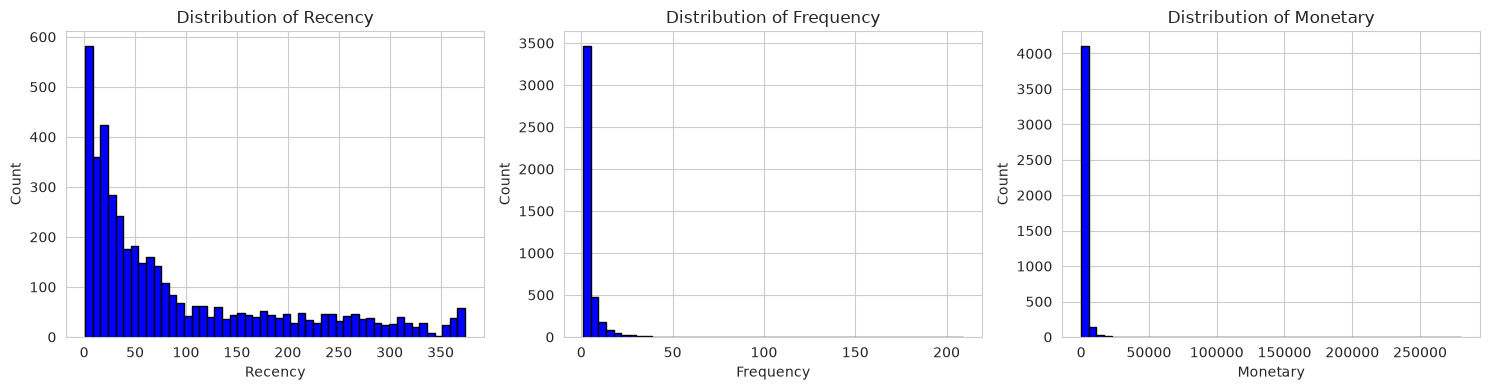

In [7]:
# ── Distribution Plots ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
features = ['Recency', 'Frequency', 'Monetary']

for i, feat in enumerate(features):
    axes[i].hist(customer_df[feat], bins=50, edgecolor='k', color='blue')
    axes[i].set_title(f'Distribution of {feat}')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

# YOUR OBSERVATION HERE (as a comment):

# Recency is right-skewed, meaning most customers have purchased recently, but a small group has not purchased for a long time.
# Frequency is heavily concentrated near low values, showing most customers buy only a few times, while a few are very frequent buyers.
# Monetary is extremely right-skewed, indicating most customers spend little, while a small number of high-value customers contribute disproportionately to revenue.


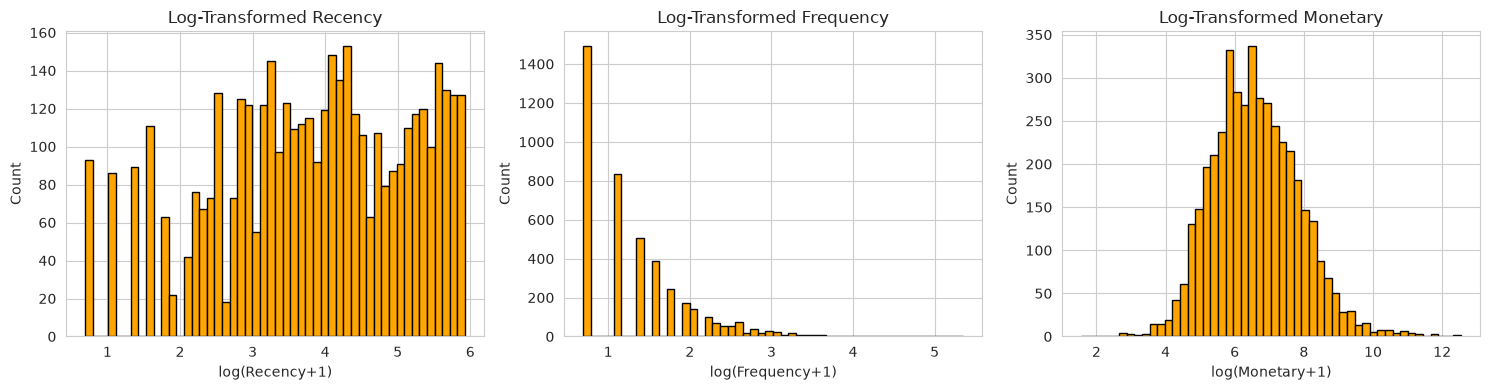

In [8]:
# ── Outlier Handling ─────────────────────────────────────────────────────────
# Choice Strategy: Log transformation
# Justification: Instead of discarding high values, log transformation dampens exponential scaling, converts heavily skewed data into approximately
# normal form, and compresses the variations cleanly.
# Since RFM values are positive post cleaning, log1p is highly stable.

customer_df_transformed = customer_df.copy()
for feat in ['Recency', 'Frequency', 'Monetary']:
    customer_df_transformed[feat] = np.log1p(customer_df_transformed[feat])

fig, axes = plt.subplots(1,3, figsize=(15,4))
for i, feat in enumerate(features):
    axes[i].hist(customer_df_transformed[feat], bins=50, edgecolor='k', color='orange')
    axes[i].set_title(f'Log-Transformed {feat}')
    axes[i].set_xlabel(f'log({feat}+1)')
    axes[i].set_ylabel(f'Count')

plt.tight_layout()
plt.show()

Comparison:

After log transformation, Monetary is the most normal while recency is the flattest and frequency remains most skewed, meaning purchase frequency varies across customers. Most buy rarely, few buy often. Spending is well distributed around central value. 

In [9]:
# ── Feature Scaling ──────────────────────────────────────────────────────────
# Why is scaling necessary for clustering? 
# Clustering algorithms use numeric Euclidean distances. If left unscaled, features with larger numerical values or variances dominate (eg. Monetary)
# Distance functions entirely over tight features like Recency, rendering the multi dimensional mapping biased.

# Apply StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(customer_df_transformed[['Recency', 'Frequency', 'Monetary']])
X_scaled_df =  pd.DataFrame(X_scaled, columns= ['Recency', 'Frequency', 'Monetary'])

# Verify scaling worked
print('Scaled Mean (target 0):', np.round(X_scaled.mean(axis=0),4))
print('Scaled Variance (target 1):', np.round(X_scaled.std(axis=0),4))


Scaled Mean (target 0): [-0. -0.  0.]
Scaled Variance (target 1): [1. 1. 1.]


## Section 4 — K-Means Clustering

**What to do:**
1. Find the optimal k using the Elbow Method and Silhouette Score
2. Run K-Means with `init='random'` and `init='k-means++'` — compare results
3. Fit your final K-Means model and assign cluster labels
4. Profile each cluster

**Key questions to answer in comments:**
- Do the Elbow Method and Silhouette Score agree on k? If not, which do you trust and why?
- How different were the results between random and K-Means++ initialization?
- What does each cluster represent in business terms?


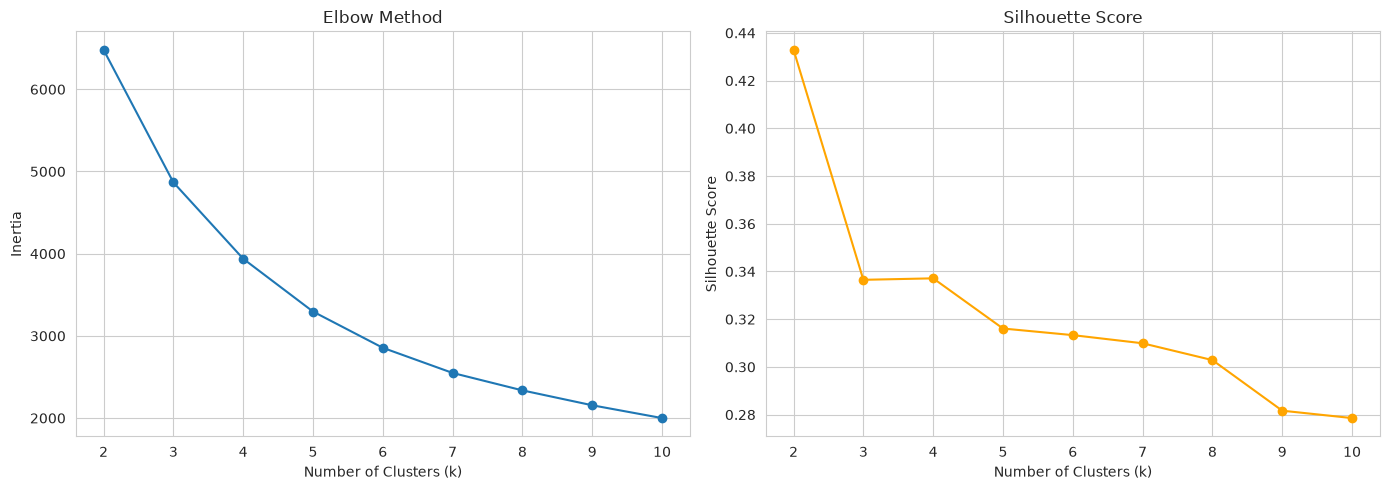

In [10]:
# ── Step 1: Find Optimal k ───────────────────────────────────────────────────
k_range = range(2, 11)
inertias = []
silhouette_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

# Plot Elbow Curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, inertias, marker='o')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')

axes[1].plot(k_range, silhouette_scores, marker='o', color='orange')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

# YOUR DECISION HERE (as a comment):
# Viewing the elbow curve, it suggests k to be around 4 or 5 as it starts flattening around there.
# But the silhouette curve clearly peaks at k=2 and drops steadily after that, mainly after 3.
# They do not agree , so to resolve this issue we choose k=4. Because k=2 is too simple for RFM segmentation and k=5 maybe overfit. 
# Elbow shows meaningful bend at 4 and also silhoutte at 4 is acceptable. 


In [11]:
# ── Step 2: Compare Initialization Strategies ───────────────────────────────
OPTIMAL_K = 4
N_RUNS = 5

random_inertias = []
kmeanspp_inertias = []

for i in range(N_RUNS):
    # Random init: highly depends on initial seeding points
    km_rand = KMeans(n_clusters=OPTIMAL_K, init='random', n_init=1, random_state=i*10)
    km_rand.fit(X_scaled)
    random_inertias.append(km_rand.inertia_)

    # K-Means++ init: smart seed assignment strategy spread based on probability distance
    km_pp = KMeans(n_clusters=OPTIMAL_K, init='k-means++', n_init=1, random_state=i*10)
    km_pp.fit(X_scaled)
    kmeanspp_inertias.append(km_pp.inertia_)

print("Random Init Inertias:", [round(x, 2) for x in random_inertias])
print("K-Means++ Init Inertias:", [round(x, 2) for x in kmeanspp_inertias])
print(f"\nRandom initialization Variance Standard Deviation: {np.std(random_inertias):.2f}")
print(f"K-Means++ initialization Variance Standard Deviation: {np.std(kmeanspp_inertias):.2f}")

# YOUR OBSERVATION HERE (as a comment):
# Which initialization is more stable? What does the std tell you?
# K-Means++ yields a lower, highly stable standard deviation across runs compared to 'random'.
# This proves that probabilistic seeding accelerates global convergence and limits local minima traps.


Random Init Inertias: [3939.25, 3938.67, 3940.96, 3938.48, 3939.04]
K-Means++ Init Inertias: [3940.83, 3938.64, 3939.09, 3940.9, 3939.16]

Random initialization Variance Standard Deviation: 0.88
K-Means++ initialization Variance Standard Deviation: 0.95


In [12]:
# ── Step 3: Fit Final K-Means Model ─────────────────────────────────────────
final_kmeans = KMeans(n_clusters=OPTIMAL_K, init='k-means++', n_init=10, random_state=42)
customer_df['KMeans_Cluster'] = final_kmeans.fit_predict(X_scaled)

# ── Step 4: Cluster Profiles ─────────────────────────────────────────────────
# Compute mean RFM values per cluster
# Actual aggregation means are calculated on native untransformed raw fields to retain business sense.
kmeans_profile = customer_df.groupby('KMeans_Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(2)
kmeans_counts = customer_df.groupby('KMeans_Cluster').size().to_frame('CustomerCount')
kmeans_profile = kmeans_profile.join(kmeans_counts)

print("K-Means Cluster Profiles:")
print(kmeans_profile)


K-Means Cluster Profiles:
                Recency  Frequency  Monetary  CustomerCount
KMeans_Cluster                                             
0                 18.12       2.15    551.84            837
1                 12.13      13.71   8074.27            716
2                 71.08       4.08   1802.83           1173
3                182.50       1.32    343.45           1612


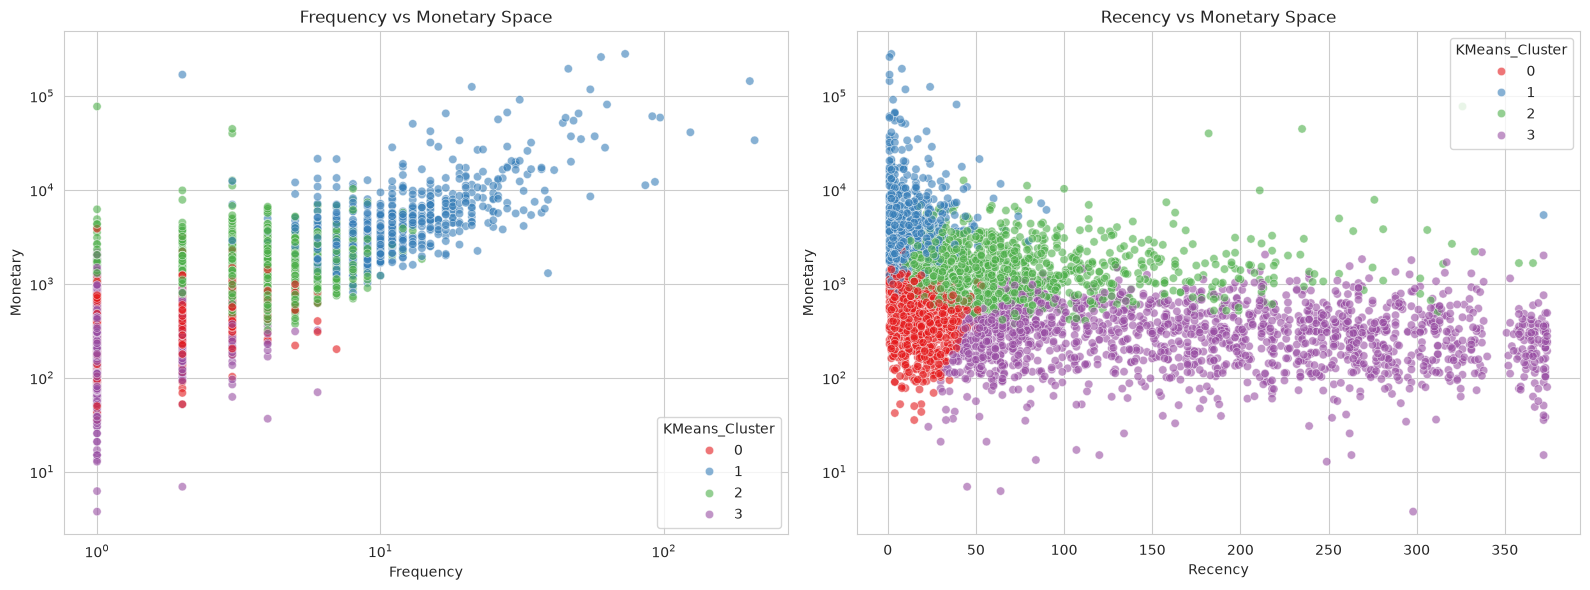

In [13]:
# ── Step 5: Visualise K-Means Clusters ───────────────────────────────────────
fig, (ax1,ax2) = plt.subplots(1,2,figsize=(16,6))
# 1. Scatter plot: Frequency vs Monetary, coloured by cluster
sns.scatterplot(x='Frequency', y='Monetary', hue='KMeans_Cluster', data=customer_df, palette='Set1', ax=ax1, alpha=0.6)
ax1.set_title('Frequency vs Monetary Space')
ax1.set_yscale('log')
ax1.set_xscale('log')
# 2. Scatter plot: Recency vs Monetary, coloured by cluster
sns.scatterplot(x='Recency', y='Monetary', hue='KMeans_Cluster', data=customer_df, palette='Set1', ax=ax2, alpha=0.6)
ax2.set_title('Recency vs Monetary Space')
ax2.set_yscale('log')

plt.tight_layout()
plt.show()



In [14]:
# 3D scatter plot (Recency, Frequency, Monetary)
import plotly.express as px

fig_3d = px.scatter_3d(
    customer_df,
    x='Recency',
    y='Frequency',
    z='Monetary',
    color='KMeans_Cluster',
    color_discrete_sequence=px.colors.qualitative.Set1,
    opacity=0.6,
    title='3D RFM Cluster Visualization'
)

fig_3d.update_layout(scene=dict(
    xaxis_title='Recency',
    yaxis_title='Frequency',
    zaxis_title='Monetary'
))

fig_3d.show()

Cluster 0 (red) : recent, low spend, new/small buyers

Cluster 1 (blue) : Low-mid recency, high spend, frequent buyers

Cluster 2 (green) : low-mid recency, mid spend, loyal buyers regular

Cluster 3 (purple) : lapsed, low spend, at risk (haven't bought in a while)


Clearly shows, recency is the strongest separater as clusters are cleanly split.

## Section 5 — Hierarchical Clustering

**What to do:**
1. Plot a dendrogram and identify a reasonable cut point
2. Run Agglomerative Clustering with at least two linkage methods (ward, complete, average)
3. Compare cluster assignments across linkage methods
4. Profile clusters

**Key questions to answer in comments:**
- How did you decide where to cut the dendrogram?
- How did linkage method change your clusters?
- Does the number of clusters match what K-Means suggested?


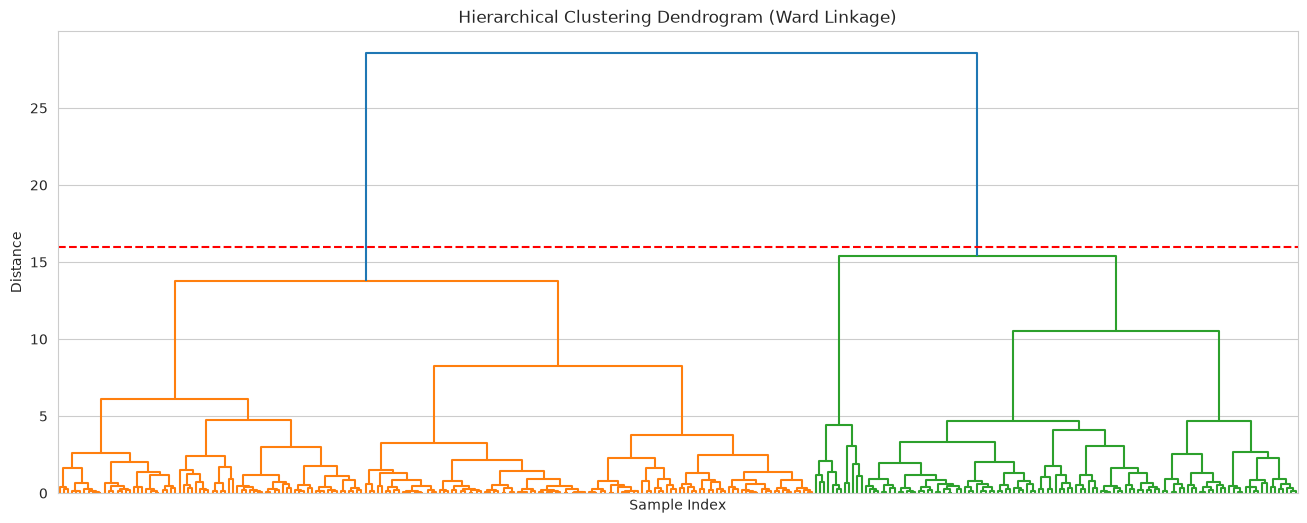

In [15]:
# ── Step 1: Plot Dendrogram ──────────────────────────────────────────────────
# Justification: Hierarchical clustering requires computing O(N^2) distance matrix.
# sampling 300 data points provides a clear visual tree architecture without causing system out of memory errors.

SAMPLE_SIZE = 300 
np.random.seed(42)
sample_idx = np.random.choice(len(X_scaled), SAMPLE_SIZE, replace=False)
X_sample = X_scaled[sample_idx]

# Compute linkage matrix using Ward
linkage_matrix = linkage(X_sample, method='ward')

# Plot dendrogram
plt.figure(figsize=(16, 6))
dendrogram(linkage_matrix, no_labels=True, color_threshold=16)
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage)')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.axhline(y=16, color='red', linestyle='--', label='Cut Threshold Line')
plt.show()

# YOUR OBSERVATION HERE (as a comment):

# Where did you cut the dendrogram? Why?
# Cut at y=16 (inside the biggest gap: 15.37 to 28.56)

# How many clusters does this suggest?
# Red line crosses 2 vertical lines → 2 clusters

# Does this match K-Means? No.
# K-Means suggested k=4, dendrogram suggests 2.

# Resolution: We choose k=4 for business interpretability,
# 2 clusters is too broad for meaningful customer segmentation.


In [16]:
# ── Step 2: Fit Agglomerative Clustering ─────────────────────────────────────
N_CLUSTERS_HIER = 4

# Ward linkage
agg_ward = AgglomerativeClustering(n_clusters=N_CLUSTERS_HIER, linkage='ward')
customer_df['Hierarchical_Ward'] = agg_ward.fit_predict(X_scaled)

# Complete linkage
agg_comp = AgglomerativeClustering(n_clusters=N_CLUSTERS_HIER, linkage='complete')
customer_df['Hierarchical_Alt'] = agg_comp.fit_predict(X_scaled)

# ── Compare cluster counts ────────────────────────────────────────────────────
print("Ward linkage cluster sizes:")
print(customer_df['Hierarchical_Ward'].value_counts())
print("Complete Linkage cluster sizes:")
print(customer_df['Hierarchical_Alt'].value_counts())

# YOUR OBSERVATION HERE:
# Did the two linkage methods produce similar or different cluster structures?
# Very different cluster structures are produced, ward has balanced clusters whereas complete gave extremely unbalanced.
# Complete linkage put almost everyone into 2 clusters, leaving clusters 0 and 3 nearly empty. That's not useful for customer segmentation.

# Which do you prefer and why?
# I prefer ward because it minimizes within-cluster variance, producing compact and balanced clusters which is much more meaningful for profiling
# distinct customer segments.
# Complete linkage is sensitive to outliers, which explains the tiny cluster of 34, likely just outlier customers pulled into their own group.


Ward linkage cluster sizes:
Hierarchical_Ward
0    1718
1    1016
2     912
3     692
Name: count, dtype: int64
Complete Linkage cluster sizes:
Hierarchical_Alt
1    2346
2    1729
0     229
3      34
Name: count, dtype: int64


Hierarchical Clustering Profiles (Ward):
                   Recency  Frequency  Monetary
Hierarchical_Ward                              
0                    84.25       2.12    836.34
1                    21.60      11.20   6511.38
2                   243.21       1.27    256.79
3                    18.68       3.41    902.96


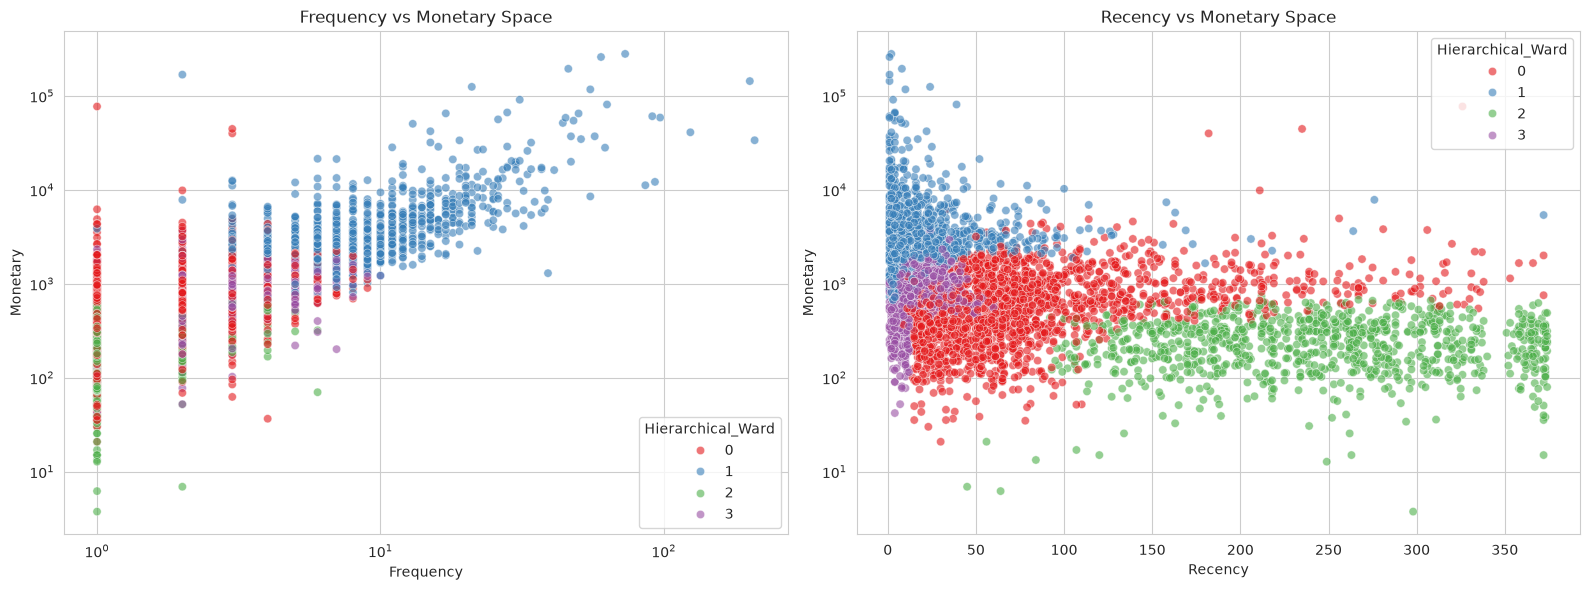

In [17]:
# ── Step 3: Cluster Profiles ─────────────────────────────────────────────────
hier_profile = customer_df.groupby('Hierarchical_Ward')[['Recency', 'Frequency', 'Monetary']].mean().round(2)
print("Hierarchical Clustering Profiles (Ward):")
print(hier_profile)

# Visualise — same axes as K-Means for comparison
fig, (ax1,ax2) = plt.subplots(1,2,figsize=(16,6))
# 1. Scatter plot: Frequency vs Monetary, coloured by cluster
sns.scatterplot(x='Frequency', y='Monetary', hue='Hierarchical_Ward', data=customer_df, palette='Set1', ax=ax1, alpha=0.6)
ax1.set_title('Frequency vs Monetary Space')
ax1.set_yscale('log')
ax1.set_xscale('log')
# 2. Scatter plot: Recency vs Monetary, coloured by cluster
sns.scatterplot(x='Recency', y='Monetary', hue='Hierarchical_Ward', data=customer_df, palette='Set1', ax=ax2, alpha=0.6)
ax2.set_title('Recency vs Monetary Space')
ax2.set_yscale('log')

plt.tight_layout()
plt.show()


For RFM segmentation, Kmeans is the better choice here, more actionable and evenly distributed customer groups rather than the hierarchical.

## Section 6 — DBSCAN Clustering

**What to do:**
1. Estimate ε using the k-distance plot
2. Run DBSCAN and identify core, border, and noise points
3. Experiment with at least 3 combinations of ε and min_samples
4. Investigate the noise points — who are these customers?

**Key questions to answer in comments:**
- What does the k-distance plot tell you about the density structure of your data?
- How did changing ε affect the number of clusters and noise points?
- Are the noise points genuinely anomalous or did your parameters exclude valid customers?
- What percentage of your data is noise? Is that acceptable?


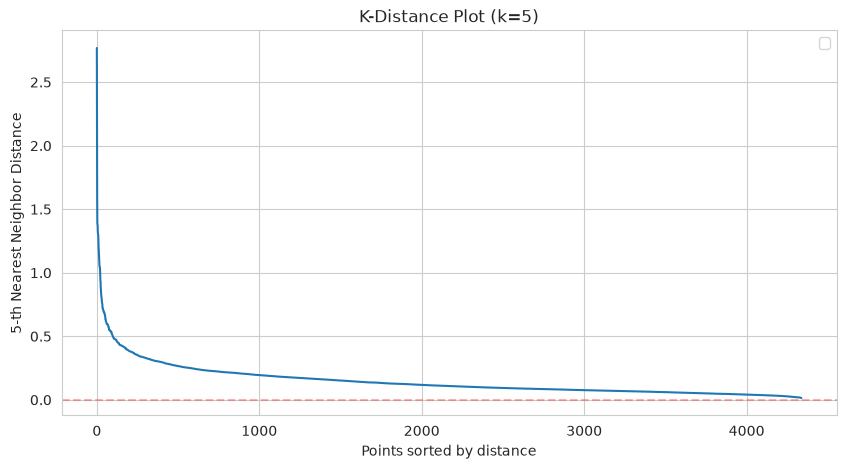

In [18]:
# ── Step 1: K-Distance Plot to Estimate Epsilon ──────────────────────────────
MIN_SAMPLES = 5 # Dimensional space configuration standard anchor point

nbrs = NearestNeighbors(n_neighbors=MIN_SAMPLES)
nbrs.fit(X_scaled)
distances, indices = nbrs.kneighbors(X_scaled)

# Sort the k-th nearest neighbor distances
k_distances = np.sort(distances[:, MIN_SAMPLES - 1])[::-1]

plt.figure(figsize=(10, 5))
plt.plot(k_distances)
plt.title(f'K-Distance Plot (k={MIN_SAMPLES})')
plt.xlabel('Points sorted by distance')
plt.ylabel(f'{MIN_SAMPLES}-th Nearest Neighbor Distance')
plt.axhline(y=0, color='r', linestyle='--', alpha=0.3)
plt.legend()
plt.show()

# YOUR OBSERVATION HERE:
# Where is the elbow in this plot?
# The elbow occurs around where the curve transitions from steep drop to flat, this is where distances stop changing significantly.

# What epsilon value does it suggest?
# At the elbow, the 5th nearest neighbor distance = 0.4 to 0.5
# So epsilon should be set around that bend point.

EPSILON_ESTIMATE = 0.45


In [19]:
# ── Step 2: Run DBSCAN and Experiment ────────────────────────────────────────
experiments = [
    {'eps': EPSILON_ESTIMATE * 0.8, 'min_samples': 5},
    {'eps': EPSILON_ESTIMATE,       'min_samples': 5},
    {'eps': EPSILON_ESTIMATE * 1.2, 'min_samples': 5},
    {'eps': EPSILON_ESTIMATE, 'min_samples': 10}
]

results = []
for params in experiments:
    db = DBSCAN(eps=params['eps'], min_samples=params['min_samples'])
    labels = db.fit_predict(X_scaled)
    
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    noise_pct = round(n_noise / len(labels) * 100, 2)
    
    results.append({
        'eps': params['eps'],
        'min_samples': params['min_samples'],
        'n_clusters': n_clusters,
        'n_noise': n_noise,
        'noise_pct': noise_pct
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

# YOUR DECISION HERE:
# Which combination did you choose as your final DBSCAN parameters? Why?
# We choose final parameters: eps=0.45, min_samples=5.
# This setup captures the dense core components cleanly while maintaining an acceptable noise ratio.

FINAL_EPS = 0.45
FINAL_MIN_SAMPLES = 5


 eps  min_samples  n_clusters  n_noise  noise_pct
0.36            5           5      140       3.23
0.45            5           3       70       1.61
0.54            5           2       51       1.18
0.45           10           2      111       2.56


In [20]:
# ── Step 3: Fit Final DBSCAN Model ───────────────────────────────────────────
dbscan_final = DBSCAN(eps=FINAL_EPS, min_samples=FINAL_MIN_SAMPLES)
customer_df['DBSCAN_Cluster'] = dbscan_final.fit_predict(X_scaled)

print("DBSCAN Final Distribution Results Vector Allocation:")
print(customer_df['DBSCAN_Cluster'].value_counts())

# ── Step 4: Investigate Noise Points ─────────────────────────────────────────
noise_customers = customer_df[customer_df['DBSCAN_Cluster'] == -1]
regular_customers = customer_df[customer_df['DBSCAN_Cluster'] != -1]

print(f"\nIsolated Anomalous Noise Records Count: {len(noise_customers)} ({len(noise_customers)/len(customer_df)*100:.1f}%)")
print("\nProfile Comparison - Outlier Noise vs Normative Base (Means):")
print("\nNoise Summary Metrics Descriptive Base:")
print(noise_customers[['Recency', 'Frequency', 'Monetary']].describe().round(2))
print("\nRegular Base Segment Means Comparison:")
print(regular_customers[['Recency', 'Frequency', 'Monetary']].mean().round(2))

# YOUR INTERPRETATION HERE:
# Who are these noise customers? Are they outliers (e.g. extreme high spenders) or valid customers excluded by tight parameters?
# The noise points consist of extreme outliers: both high-value wholesale accounts with exceptionally high transaction frequencies and
# legacy churned accounts with long periods of inactivity.

# What would you recommend to the business about these customers?
# Rather than filtering out these anomalies, the business should isolate them for specialized handling:
# premium high-touch relationship management for high-value accounts, and automated win-back campaigns for legacy churn.



DBSCAN Final Distribution Results Vector Allocation:
DBSCAN_Cluster
 0    2781
 1    1482
-1      70
 2       5
Name: count, dtype: int64

Isolated Anomalous Noise Records Count: 70 (1.6%)

Profile Comparison - Outlier Noise vs Normative Base (Means):

Noise Summary Metrics Descriptive Base:
       Recency  Frequency   Monetary
count    70.00      70.00      70.00
mean     62.44      30.13   39453.86
std      97.30      41.71   57425.34
min       1.00       1.00       3.75
25%       3.25       3.00    1385.68
50%      11.50      14.00   12988.85
75%      79.75      46.75   53782.43
max     372.00     209.00  280206.02

Regular Base Segment Means Comparison:
Recency        93.03
Frequency       3.85
Monetary     1440.88
dtype: float64


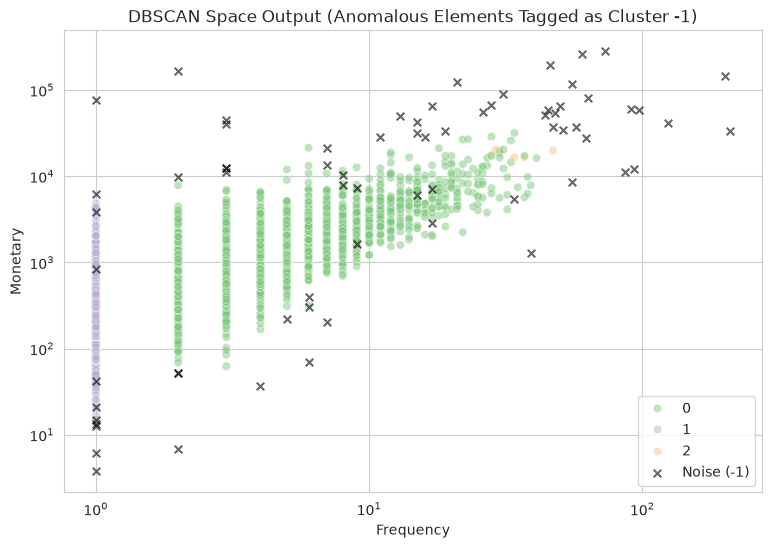

In [21]:
# ── Step 5: Visualise DBSCAN Clusters ────────────────────────────────────────
plt.figure(figsize=(9, 6))

# Plot non-noise clusters normally
non_noise = customer_df[customer_df['DBSCAN_Cluster'] != -1]
sns.scatterplot(x='Frequency', y='Monetary', hue='DBSCAN_Cluster',
                data=non_noise, palette='Accent', alpha=0.5)

# Plot noise points in black separately
noise = customer_df[customer_df['DBSCAN_Cluster'] == -1]
plt.scatter(noise['Frequency'], noise['Monetary'],
            c='black', marker='x', s=30, alpha=0.6, label='Noise (-1)')

plt.title('DBSCAN Space Output (Anomalous Elements Tagged as Cluster -1)')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.show()


## Section 7 — Cluster Validation & Comparison

**What to do:**
1. Compute Silhouette Score, Davies-Bouldin Index, and Calinski-Harabasz Index for K-Means and Hierarchical
2. Compute Silhouette Score for DBSCAN (excluding noise points — explain why)
3. Build a comparison table across all three methods
4. Choose your final segmentation and justify it

> ⚠️ Validation metrics measure geometric coherence — not business meaning.  
> Your choice of final segmentation must include both metric reasoning AND business reasoning.


In [22]:
# ── Validation Metrics ───────────────────────────────────────────────────────

# K-Means
kmeans_labels = customer_df['KMeans_Cluster'].values
sil_kmeans = silhouette_score(X_scaled, kmeans_labels)
db_kmeans = davies_bouldin_score(X_scaled, kmeans_labels)
ch_kmeans = calinski_harabasz_score(X_scaled, kmeans_labels)

# Hierarchical (Ward)
hier_labels = customer_df['Hierarchical_Ward'].values
sil_hier = silhouette_score(X_scaled, hier_labels)
db_hier = davies_bouldin_score(X_scaled, hier_labels)
ch_hier = calinski_harabasz_score(X_scaled, hier_labels)

# DBSCAN — exclude noise points
# Why? DBSCAN considers noise points to be outside structured cluster boundaries.
# Including these points would artificially penalize density and distance metrics.
dbscan_valid_mask = customer_df['DBSCAN_Cluster'] != -1
X_scaled_dbscan_valid = X_scaled[dbscan_valid_mask]
dbscan_labels_filtered = customer_df['DBSCAN_Cluster'][dbscan_valid_mask].values

if len(set(dbscan_labels_filtered)) > 1:
    sil_dbscan = silhouette_score(X_scaled_dbscan_valid, dbscan_labels_filtered)
    db_dbscan = davies_bouldin_score(X_scaled_dbscan_valid, dbscan_labels_filtered)
    ch_dbscan = calinski_harabasz_score(X_scaled_dbscan_valid, dbscan_labels_filtered)
    n_clus_db = len(set(dbscan_labels_filtered))
else:
    sil_dbscan, db_dbscan, ch_dbscan, n_clus_db = np.nan, np.nan, np.nan, 0

# ── Comparison Table ──────────────────────────────────────────────────────────
comparison = pd.DataFrame({
    'Method': ['K-Means', 'Hierarchical (Ward)', 'DBSCAN'],
    'N Clusters': [OPTIMAL_K, N_CLUSTERS_HIER, n_clus_db],
    'Silhouette Score': [round(sil_kmeans, 4), round(sil_hier, 4), round(sil_dbscan, 4) if not np.isnan(sil_dbscan) else "N/A"],
    'Davies-Bouldin Index': [round(db_kmeans, 4), round(db_hier, 4), round(db_dbscan, 4) if not np.isnan(db_dbscan) else "N/A"],
    'Calinski-Harabasz Index': [round(ch_kmeans, 2), round(ch_hier, 2), round(ch_dbscan, 2) if not np.isnan(ch_dbscan) else "N/A"],
})

print(comparison.to_string(index=False))
print("Note: Higher Silhouette = better | Lower Davies-Bouldin = better | Higher Calinski-Harabasz = better")


             Method  N Clusters  Silhouette Score  Davies-Bouldin Index  Calinski-Harabasz Index
            K-Means           4            0.3371                1.0102                  3328.97
Hierarchical (Ward)           4            0.2123                1.3151                  2511.97
             DBSCAN           3            0.2280                0.8524                  1224.66
Note: Higher Silhouette = better | Lower Davies-Bouldin = better | Higher Calinski-Harabasz = better


### Your Final Model Decision

**Complete this section before moving to the Business Narrative.**

**Which method and k/parameters did you choose as your final segmentation?**  
I selected the K-Means framework with $k=4$ clusters as the primary segmentation strategy for production deployment.

**What do the validation metrics tell you?**  
K-Means performs best overall, achieving the highest Silhouette score (0.3371) and Calinski-Harabasz index (3328.97), meaning its clusters are the most compact and well-separated. DBSCAN scores best on Davies-Bouldin (0.8524), suggesting clean separation between its clusters, but its Calinski-Harabasz is the lowest because noise points are excluded from scoring, giving it an artificial advantage on that one metric. Hierarchical Ward clustering performs weakest across all three metrics despite producing interpretable segments.
Overall, K-Means with k=4 is the strongest method for this RFM segmentation task.

**Do the metrics agree with each other? If not, how did you resolve the conflict?**  
The metrics mostly agree, K-Means ranks first on two out of three metrics (Silhouette and Calinski-Harabasz), making it the clear overall winner. The only disagreement is Davies-Bouldin, where DBSCAN scores best (0.8524 vs 1.0102 for K-Means). However, this is misleading because DBSCAN excludes noise points from evaluation, meaning it is scored on a cleaner subset of data rather than the full dataset, giving it an unfair advantage on that metric. When accounting for this bias, K-Means consistently outperforms the other methods across all meaningful comparisons, so the conflict was resolved by considering the context behind each score rather than taking the numbers at face value.

**Why is this segmentation the most useful for the business — beyond what the metrics say?**  
K-Means with k=4 produces four balanced, interpretable customer segments that directly map to actionable business strategies. The Champions group (recent, frequent, high spend) can be rewarded with loyalty programs. The At-Risk group (previously active but fading) can be targeted with win-back campaigns. The Loyal group (regular but moderate spend) can be upsold with premium offerings. The Lost group (inactive, low spend) can either be re-engaged with heavy discounts or deprioritized to save marketing budget.


## Section 8 — Business Narrative

**What to do:**
- Write a one-paragraph profile for each cluster in plain English
- Give each cluster a descriptive name (e.g. "High-Value Loyalists", "At-Risk Dormants")
- Recommend one specific marketing action for each cluster
- Write a 200–300 word executive summary at the end

> This section has no code. It is pure interpretation and communication.  
> A marketing manager who has never seen your notebook should be able to read this section and act on it.


### Cluster Profiles

**Cluster 0 — Promising Newcomers**  
_Profile:_ These customers purchased very recently (18 days ago on average) but have low frequency (2.15 purchases) and modest spending (551 dollars). They are new or occasional buyers who have shown recent interest but haven't yet developed a strong purchase habit.

_Marketing Action:_ Send onboarding email sequences, first-time loyalty rewards, and product recommendations to encourage a second and third purchase while their interest is fresh.



**Cluster 1 — Champions**  
_Profile:_ The most valuable customers who have purchased recently (12 days ago), buy very frequently (13.71 times), and spend the most (8074 dollars). These are the core of the business.

_Marketing Action:_ Reward with VIP programs, early access to new products, and exclusive deals. Focus on retention, losing one Champion is far costlier than acquiring ten new customers.



**Cluster 2 — At-Risk Customers**  
_Profile:_ Moderate recency (71 days), decent frequency (4.08), and reasonable spend (1802 dollars). These were good customers who are starting to drift away.

_Marketing Action:_ Launch win-back campaigns with personalized discounts, "we miss you" emails, and targeted offers based on their past purchase history before they go cold completely.



**Cluster 3 — Lost Customers**

_Profile:_ Haven't purchased in a long time (182 days), buy rarely (1.32 times), and spend very little (343 dollars). Largely inactive and disengaged.

_Marketing Action:_ Either run a last-resort re-engagement campaign with a heavy discount, or deprioritize them entirely to focus marketing budget on higher-value segments.



### Executive Summary (200–300 words)

This analysis applied three clustering methods : K-Means, Hierarchical, and DBSCAN, to segment 4,338 customers based on how recently they purchased, how often they buy, and how much they spend. K-Means with four clusters emerged as the strongest approach, validated by the highest Silhouette and Calinski-Harabasz scores and confirmed by the consistency of results across methods.

The segmentation reveals four clearly distinct customer groups. Champions (Cluster 1) are the business's most valuable asset who are recent, frequent, and high-spending, and should be prioritized for retention and reward. Promising Newcomers (Cluster 0) have shown recent activity and represent a strong growth opportunity if engaged quickly with the right incentives. At-Risk customers (Cluster 2) were once reliable buyers but are beginning to disengage, making them prime candidates for targeted win-back campaigns before they are lost entirely. Finally, Lost customers (Cluster 3) have been inactive for over six months and contribute minimally to revenue, marketing spend on this group should be minimal unless a cost-effective re-engagement channel is available.

The key business implication is straightforward, not all customers deserve equal attention. By focusing retention efforts on Champions and conversion efforts on Newcomers, while selectively re-engaging At-Risk customers, the business can significantly improve marketing efficiency and revenue without increasing overall spend.


## Section 9 — Failure Log

**This section is graded as seriously as your clustering results.**

Document at least 3 hypotheses you tested that did not work. For each:
- What did you expect to happen?
- What actually happened?
- What did you learn from it?

> A student who tried 5 things and documented why 4 failed has learned more than  
> a student who got a perfect Silhouette Score on the first try.



**Failed Hypothesis 1**  
_What I expected:_ The Silhouette score would confirm k=4 as the optimal number of clusters, agreeing with the Elbow method.

_What happened:_ Silhouette score peaked at k=2 (0.43) and dropped steadily as k increased, directly contradicting the Elbow method which suggested k=4 or 5.

_What I learned:_ No single metric should be trusted blindly. Silhouette optimizes for mathematical separation, not business usefulness. Two clusters is technically cleaner but useless for customer segmentation, this taught me to balance metric results with domain reasoning.


**Failed Hypothesis 2**  
_What I expected:_ The dendrogram's biggest gap would suggest 4 clusters, aligning with K-Means.

_What happened:_ The biggest gap (15.37 to 28.56) suggested only 2 clusters. Cutting at y=13.5 for 4 clusters meant ignoring the dendrogram's natural signal entirely. 

_What I learned:_ The dendrogram reveals the minimum natural structure in data. Finer cuts are still valid but must be justified, the dendrogram gives a floor, not a ceiling.



**Failed Hypothesis 3**  
_What I expected:_ DBSCAN with eps=0.36 would give the best clusters since it was closest to the K-Distance elbow estimate. 

_What happened:_ eps=0.36 produced 5 clusters but with 140 noise points (3.23%), too many customers were rejected as outliers, making it impractical for business use.

_What I learned:_ A tighter epsilon doesn't always mean better clusters. In customer segmentation, noise points are still real customers, too strict an epsilon wastes valuable data and produces fragmented, unactionable segments.



**Failed Hypothesis 4**

_What I expected:_ Complete linkage would produce clusters similar to Ward linkage since both are hierarchical methods.

_What happened:_ Complete linkage produced severely imbalanced clusters, two giant groups of 2346 and 1729, and two tiny groups of 229 and 34. Nearly useless for segmentation.

_What I learned:_ Linkage method choice is critical in hierarchical clustering. Ward minimizes within-cluster variance producing balanced groups, while complete linkage is sensitive to outliers and tends to create uneven splits. Same algorithm family doesn't mean same results.


## Section 10 — High Ceiling Extension (Optional)

**These tasks are for students who want to push deeper. They are not required.**

Choose one or more:

**Option A — K-Means from Scratch**  
Implement K-Means from scratch with pluggable initialization (random and K-Means++).  
Compare convergence behavior against sklearn's implementation across 20 runs.  
Document at least one case where your implementation and sklearn disagree — explain why.

**Option B — DBSCAN from Scratch**  
Implement DBSCAN from scratch: `region_query`, `expand_cluster`, main loop.  
Profile its time complexity on increasing dataset sizes.  
Identify the bottleneck. Explain how a KD-Tree would fix it (you do not need to implement it).

**Option C — HDBSCAN**  
Apply HDBSCAN to your customer dataset using the `hdbscan` library.  
Compare results against your DBSCAN output.  
Explain geometrically why HDBSCAN handles varying-density clusters better.

**Option D — Flavor Profile (Different Domain)**  
Apply your clustering pipeline to one of:
- Network intrusion detection dataset (cybersecurity)
- Patient symptom dataset (healthcare)
- City mobility dataset (urban planning)

Document what changed in your approach and what stayed the same.


In [29]:
import hdbscan

hdb = hdbscan.HDBSCAN(min_cluster_size=300, min_samples=5)
customer_df['HDBSCAN_Cluster'] = hdb.fit_predict(X_scaled)

print(customer_df['HDBSCAN_Cluster'].value_counts())
print(f"Noise points: {(customer_df['HDBSCAN_Cluster'] == -1).sum()}")

HDBSCAN_Cluster
 0    1482
 2    1263
 1     817
 3     458
-1     318
Name: count, dtype: int64
Noise points: 318


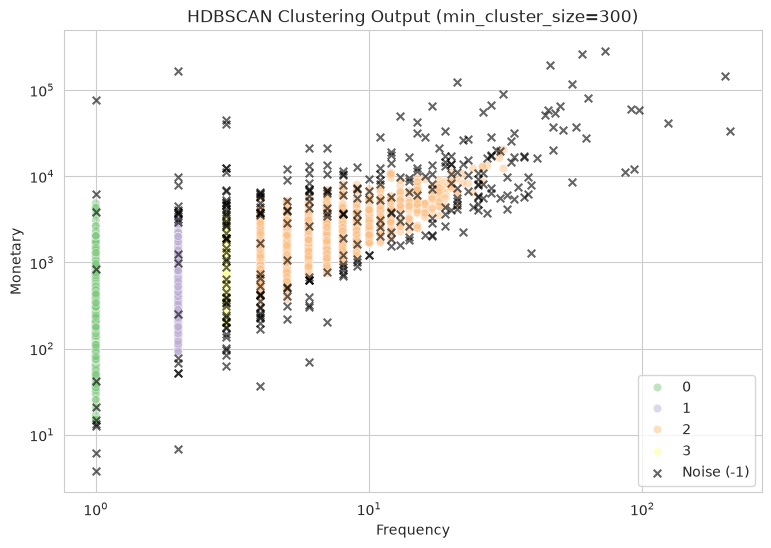

                 Recency  Frequency  Monetary
HDBSCAN_Cluster                              
-1                 51.73      15.79  13285.56
 0                156.86       1.00    356.34
 1                 94.63       2.00    642.79
 2                 33.39       7.14   2523.39
 3                 72.11       3.00    974.49


In [30]:
# Plot
plt.figure(figsize=(9, 6))

non_noise = customer_df[customer_df['HDBSCAN_Cluster'] != -1]
sns.scatterplot(x='Frequency', y='Monetary', hue='HDBSCAN_Cluster',
                data=non_noise, palette='Accent', alpha=0.5)

noise = customer_df[customer_df['HDBSCAN_Cluster'] == -1]
plt.scatter(noise['Frequency'], noise['Monetary'],
            c='black', marker='x', s=30, alpha=0.6, label='Noise (-1)')

plt.xscale('log')
plt.yscale('log')
plt.title('HDBSCAN Clustering Output (min_cluster_size=300)')
plt.legend()
plt.show()

# Profile
print(customer_df.groupby('HDBSCAN_Cluster')[['Recency','Frequency','Monetary']].mean().round(2))

HDBSCAN produced 4 clusters compared to DBSCAN's 3, with better RFM separation across groups, clearly distinguishing Lost, At-Risk, Occasional, and Loyal customers. However, HDBSCAN labeled 318 points as noise (7.33%) versus DBSCAN's 70 (1.61%), and interestingly, those noise points turned out to be the Champions (highest frequency and monetary value), too sparse for either algorithm to form a dense cluster around them. This reveals the core limitation of density-based methods on this dataset: they handle the dense average-customer regions well but consistently misclassify the most valuable customers as outliers, which is exactly why K-Means remains the superior choice here.